In [1]:
import argparse
import torch
from torch import nn, Tensor, optim
from typing import Optional, Union, Tuple, List, Any
import torch.optim as optim
from torch.ao.quantization import QuantStub, DeQuantStub
from torch.nn.quantized import FloatFunctional


import os
import json
import random
import numpy as np
from torch.utils.data import Dataset, DataLoader, RandomSampler
from torchvision import transforms
from PIL import Image
from tqdm import tqdm
from pycocotools.coco import COCO
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode
import matplotlib.pyplot as plt
import torchvision.transforms as T

from cv_nets.utils.config_helper import get_param
from cv_nets.layers.activation import build_activation_layer
from cv_nets.layers.normalization import build_normalization_layer
from cv_nets.layers.pooling import build_pooling_layer
from cv_nets.layers import *

In [2]:
IMAGE_SIZE = (320, 320)
BATCH_SIZE = 16
NUM_WORKERS = 16
EPOCH = 100


TRAIN_IMG_DIR = './COCO/train2017'
TRAIN_ANN_FILE = './COCO/annotations/instances_train2017.json'

VAL_IMG_DIR = './COCO/val2017'
VAL_ANN_FILE = './COCO/annotations/instances_val2017.json'

SAVE_MODEL_DIR = './models/unet_base'

patience = 15                 # Số lượng epoch tối đa không giảm val_loss trước khi dừng
min_epochs_before_stop = 30  # Chỉ bắt đầu xét Early Stopping khi qua mốc này

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Đang sử dụng thiết bị: {device}")


Đang sử dụng thiết bị: cuda


In [3]:
class MV2Block(nn.Module):
    """
    Inverted Residual Block của MobileNetV2.
    Dùng depthwise separable conv để giảm tham số và FLOPs.
    """
    def __init__(
        self,
        opts: Any,
        in_channels: int,
        out_channels: int,
        expand_ratio: int = 2
    ) -> None:
        super().__init__()
        hidden_dim = in_channels * expand_ratio
        self.use_res_connect = (in_channels == out_channels)
        self.f_add = FloatFunctional()

        layers = []

        # 1x1 expansion
        if expand_ratio != 1:
            layers.extend([
                Conv2d(
                    in_channels=in_channels,
                    out_channels=hidden_dim,
                    kernel_size=1,
                    stride=1,
                    padding=0,
                    opts=opts
                ),
                build_normalization_layer(opts, num_features=hidden_dim),
                build_activation_layer(opts),
            ])
        else:
            hidden_dim = in_channels

        # 3x3 depthwise
        layers.extend([
            Conv2d(
                in_channels=hidden_dim,
                out_channels=hidden_dim,
                kernel_size=3,
                stride=1,
                padding=1,
                groups=hidden_dim,
                opts=opts
            ),
            build_normalization_layer(opts, num_features=hidden_dim),
            build_activation_layer(opts),
        ])

        # 1x1 projection
        layers.extend([
            Conv2d(
                in_channels=hidden_dim,
                out_channels=out_channels,
                kernel_size=1,
                stride=1,
                padding=0,
                opts=opts
            ),
            build_normalization_layer(opts, num_features=out_channels),
        ])

        self.block = nn.Sequential(*layers)

    def forward(self, x: Tensor) -> Tensor:
        out = self.block(x)
        if self.use_res_connect:
            return self.f_add.add(x, out)
        return out


class Attention2DWrapper(nn.Module):
    """
    Bọc LinearSelfAttention để dùng trực tiếp với tensor [B, C, H, W].

    Quy ước:
    - Input:  [B, C, H, W]
    - Unfold: [B, C, P, N]
      trong đó P = patch_size * patch_size
               N = số patch
    - Output: [B, C, H, W]
    """
    def __init__(self, opts: Any, embed_dim: int, patch_size: int = 2) -> None:
        super().__init__()
        self.patch_size = patch_size
        self.P = patch_size * patch_size
        self.attn = LinearSelfAttention(opts=opts, embed_dim=embed_dim)

    def unfold(self, x: Tensor):
        b, c, h, w = x.shape
        ph = pw = self.patch_size

        if h % ph != 0 or w % pw != 0:
            raise ValueError(
                f"Feature map size ({h}, {w}) must be divisible by patch_size={self.patch_size}"
            )

        num_h, num_w = h // ph, w // pw
        n = num_h * num_w

        # [B, C, H, W] -> [B, C, num_h, ph, num_w, pw]
        x = x.view(b, c, num_h, ph, num_w, pw)
        # -> [B, C, num_h, num_w, ph, pw]
        x = x.permute(0, 1, 2, 4, 3, 5).contiguous()
        # -> [B, C, N, P]
        x = x.view(b, c, n, self.P)
        # -> [B, C, P, N]
        x = x.permute(0, 1, 3, 2).contiguous()
        return x, (num_h, num_w)

    def fold(self, x: Tensor, grid_shape: tuple):
        b, c, p, n = x.shape
        num_h, num_w = grid_shape
        ph = pw = self.patch_size

        h, w = num_h * ph, num_w * pw

        # [B, C, P, N] -> [B, C, N, P]
        x = x.permute(0, 1, 3, 2).contiguous()
        # -> [B, C, num_h, num_w, ph, pw]
        x = x.view(b, c, num_h, num_w, ph, pw)
        # -> [B, C, num_h, ph, num_w, pw]
        x = x.permute(0, 1, 2, 4, 3, 5).contiguous()
        # -> [B, C, H, W]
        x = x.view(b, c, h, w)
        return x

    def forward(self, x: Tensor, x_prev: Optional[Tensor] = None) -> Tensor:
        x_patch, shape_x = self.unfold(x)

        if x_prev is None:
            out_patch = self.attn(x=x_patch)
        else:
            x_prev_patch, _ = self.unfold(x_prev)
            out_patch = self.attn(x=x_patch, x_prev=x_prev_patch)

        return self.fold(out_patch, shape_x)


class UNetMobileViT(nn.Module):
    """
    Hybrid U-Net + MobileNetV2 + MobileViTv2-style Linear Self Attention.

    Thiết kế tiết kiệm VRAM:
    - attention ở bottleneck
    - attention ở 2 decoder stage sâu nhất
    - 2 decoder stage còn lại dùng residual add
    """
    def __init__(self, opts: Any = None, num_classes: int = 1) -> None:
        super().__init__()

        features = [16, 32, 64, 128]

        self.quant = QuantStub()
        self.dequant = DeQuantStub()
        self.f_add = FloatFunctional()

        # -----------------------------
        # Encoder
        # -----------------------------
        self.encoder_blocks = nn.ModuleList()
        self.downsample_layers = nn.ModuleList()

        in_ch = 3
        for feat in features:
            self.encoder_blocks.append(
                MV2Block(
                    opts=opts,
                    in_channels=in_ch,
                    out_channels=feat,
                    expand_ratio=2
                )
            )
            self.downsample_layers.append(
                Conv2d(
                    in_channels=feat,
                    out_channels=feat,
                    kernel_size=2,
                    stride=2,
                    padding=0,
                    opts=opts
                )
            )
            in_ch = feat

        # -----------------------------
        # Bottleneck
        # -----------------------------
        bottleneck_dim = features[-1] * 2  # 128 -> 256
        self.bottleneck_in = MV2Block(
            opts=opts,
            in_channels=features[-1],
            out_channels=bottleneck_dim,
            expand_ratio=2
        )
        self.bottleneck_attn = Attention2DWrapper(
            opts=opts,
            embed_dim=bottleneck_dim,
            patch_size=2
        )
        self.bottleneck_out = MV2Block(
            opts=opts,
            in_channels=bottleneck_dim,
            out_channels=bottleneck_dim,
            expand_ratio=2
        )

        # -----------------------------
        # Decoder
        # -----------------------------
        self.decoder_blocks = nn.ModuleList()
        self.upsample_layers = nn.ModuleList()
        self.cross_attns = nn.ModuleList()

        decoder_feats = list(reversed(features))  # [128, 64, 32, 16]

        for idx, feat in enumerate(decoder_feats):
            # upsample from current channels to feat channels
            self.upsample_layers.append(
                ConvTranspose2d(
                    in_channels=feat * 2 if idx == 0 else decoder_feats[idx - 1],
                    out_channels=feat,
                    kernel_size=2,
                    stride=2,
                    padding=0,
                    opts=opts
                )
            )

            # Chỉ giữ attention ở 2 stage sâu nhất (128, 64)
            if idx < 2:
                self.cross_attns.append(
                    Attention2DWrapper(
                        opts=opts,
                        embed_dim=feat,
                        patch_size=2
                    )
                )
            else:
                self.cross_attns.append(None)

            self.decoder_blocks.append(
                MV2Block(
                    opts=opts,
                    in_channels=feat,
                    out_channels=feat,
                    expand_ratio=2
                )
            )

        self.final_conv = Conv2d(
            in_channels=features[0],
            out_channels=num_classes,
            kernel_size=1,
            stride=1,
            padding=0,
            opts=opts
        )

    def forward(self, x: Tensor) -> Tensor:
        x = self.quant(x)

        # Encoder
        skip_connections: List[Tensor] = []
        for i in range(len(self.encoder_blocks)):
            x = self.encoder_blocks[i](x)
            skip_connections.append(x)
            x = self.downsample_layers[i](x)

        # Bottleneck
        x = self.bottleneck_in(x)
        x = self.bottleneck_attn(x)
        x = self.bottleneck_out(x)

        # Decoder
        skip_connections = skip_connections[::-1]
        for i in range(len(self.decoder_blocks)):
            x = self.upsample_layers[i](x)
            skip_connection = skip_connections[i]

            if self.cross_attns[i] is not None:
                x = self.cross_attns[i](x=x, x_prev=skip_connection)
            else:
                x = self.f_add.add(x, skip_connection)

            x = self.decoder_blocks[i](x)

        x = self.final_conv(x)
        x = self.dequant(x)
        return x

In [4]:
model = UNetMobileViT(num_classes= 1)
print(model)

UNetMobileViT(
  (quant): QuantStub()
  (dequant): DeQuantStub()
  (f_add): FloatFunctional(
    (activation_post_process): Identity()
  )
  (encoder_blocks): ModuleList(
    (0): MV2Block(
      (f_add): FloatFunctional(
        (activation_post_process): Identity()
      )
      (block): Sequential(
        (0): Conv2d(3, 6, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU : inplace False
        (3): Conv2d(6, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=6, bias=False)
        (4): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU : inplace False
        (6): Conv2d(6, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (7): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (1): MV2Block(
      (f_add): FloatFunctional(
        (activation_post_process): Identi

In [5]:
class COCOPersonDataset(Dataset):
    """
    Dataset tùy chỉnh với Data Augmentation đồng bộ (Resize cạnh ngắn -> Random Crop)
    """
    def __init__(self, img_dir, ann_file, image_size=IMAGE_SIZE, is_train=True):
        self.img_dir = img_dir
        self.coco = COCO(ann_file)
        self.image_size = image_size
        self.is_train = is_train 
        
        self.person_cat_id = self.coco.getCatIds(catNms=['person'])[0]
        self.img_ids = self.coco.getImgIds(catIds=[self.person_cat_id])

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        img_id = self.img_ids[idx]
        img_info = self.coco.loadImgs(img_id)[0]
        img_path = os.path.join(self.img_dir, img_info['file_name'])
        image = Image.open(img_path).convert('RGB')
        
        ann_ids = self.coco.getAnnIds(imgIds=img_id, catIds=[self.person_cat_id], iscrowd=None)
        anns = self.coco.loadAnns(ann_ids)
        
        mask = np.zeros((img_info['height'], img_info['width']), dtype=np.uint8)
        for ann in anns:
            mask = np.maximum(mask, self.coco.annToMask(ann))
        mask = Image.fromarray(mask * 255).convert('L')

        if self.is_train:
            # 1. Random Scale: Đổi kích thước cạnh ngắn ngẫu nhiên thay vì cố định
            # Ví dụ: Kích thước thật là 320, ta scale ngẫu nhiên từ 320 đến 480
            short_edge = random.randint(min(self.image_size), int(min(self.image_size) * 1.5))
            image = TF.resize(image, short_edge, interpolation=InterpolationMode.BILINEAR)
            mask = TF.resize(mask, short_edge, interpolation=InterpolationMode.NEAREST)

            # 2. Random Rotation: Xoay ngẫu nhiên từ -15 đến 15 độ
            if random.random() > 0.5:
                angle = random.uniform(-15, 15)
                image = TF.rotate(image, angle, interpolation=InterpolationMode.BILINEAR)
                mask = TF.rotate(mask, angle, interpolation=InterpolationMode.NEAREST)

            # 3. Random Crop (Như cũ của bạn)
            i, j, h, w = T.RandomCrop.get_params(image, output_size=self.image_size)
            image = TF.crop(image, i, j, h, w)
            mask = TF.crop(mask, i, j, h, w)
            
            # 4. Random Horizontal Flip (Như cũ)
            if random.random() > 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask)

            # 5. Color Jitter (Chỉ áp dụng cho Image, KHÔNG áp dụng cho Mask)
            if random.random() > 0.5:
                # Bạn có thể định nghĩa T.ColorJitter ở __init__ để code gọn hơn
                jitter = T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1)
                image = jitter(image)
                
            # 6. Gaussian Blur (Chỉ áp dụng cho Image)
            if random.random() > 0.7: # Tỷ lệ thấp thôi, vì ảnh mờ quá cũng không tốt
                blur_transform = T.GaussianBlur(kernel_size=(3, 5), sigma=(0.1, 2.0))
                image = blur_transform(image)

        else:
            # Quy trình cho tập Validation giữ nguyên
            short_edge = min(self.image_size)
            image = TF.resize(image, short_edge, interpolation=InterpolationMode.BILINEAR)
            mask = TF.resize(mask, short_edge, interpolation=InterpolationMode.NEAREST)
            image = TF.center_crop(image, self.image_size)
            mask = TF.center_crop(mask, self.image_size)

        # Chuyển thành Tensor và Normalize
        image_tensor = TF.to_tensor(image)
        image_tensor = TF.normalize(image_tensor, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        
        mask_tensor = TF.to_tensor(mask) 
        
        return image_tensor, mask_tensor

In [6]:
def calculate_iou(preds, masks, threshold=0.5):
    """Tính Intersection over Union (IoU) cho Segmentation"""
    preds = torch.sigmoid(preds) > threshold
    masks = masks > threshold
    
    intersection = (preds & masks).float().sum((1, 2, 3))
    union = (preds | masks).float().sum((1, 2, 3))
    
    iou = (intersection + 1e-6) / (union + 1e-6)
    return iou.mean().item()

In [7]:
def visualize_datasets(dataloader, num_samples=8):
    """
    Trực quan hóa kết quả dự đoán của mô hình Segmentation.
    Mỗi sample hiển thị: Ảnh gốc | Ground Truth | Prediction.
    """
    
    samples_shown = 0
    fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 14))
    plt.subplots_adjust(wspace=0.1, hspace=0.3)
    
    inv_normalize = transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )

    with torch.no_grad():
        for images, masks in dataloader:

            for i in range(images.size(0)):
                if samples_shown >= num_samples:
                    break
                
                row = samples_shown // 2
                col_offset = (samples_shown % 2) * 2

                img = inv_normalize(images[i]).permute(1, 2, 0).numpy()
                img = np.clip(img, 0, 1)

                gt_mask = masks[i].squeeze().numpy()

                ax_img = axes[row, col_offset]
                ax_img.imshow(img)
                ax_img.set_title(f"Sample {samples_shown+1}: Image")
                ax_img.axis('off')
                ax_gt = axes[row, col_offset + 1]
                ax_gt.imshow(gt_mask, cmap='gray')
                ax_gt.set_title("Ground Truth")
                ax_gt.axis('off')

                samples_shown += 1

            if samples_shown >= num_samples:
                break

    plt.suptitle("Dữ liệu mẫu Segmentation (Input | Ground Truth)", fontsize=16, y=0.92)
    plt.show()

In [8]:
print("Đang tải COCO Train Annotations...")
train_dataset = COCOPersonDataset(TRAIN_IMG_DIR, TRAIN_ANN_FILE, image_size=(320, 320))

Đang tải COCO Train Annotations...
loading annotations into memory...
Done (t=10.27s)
creating index...
index created!


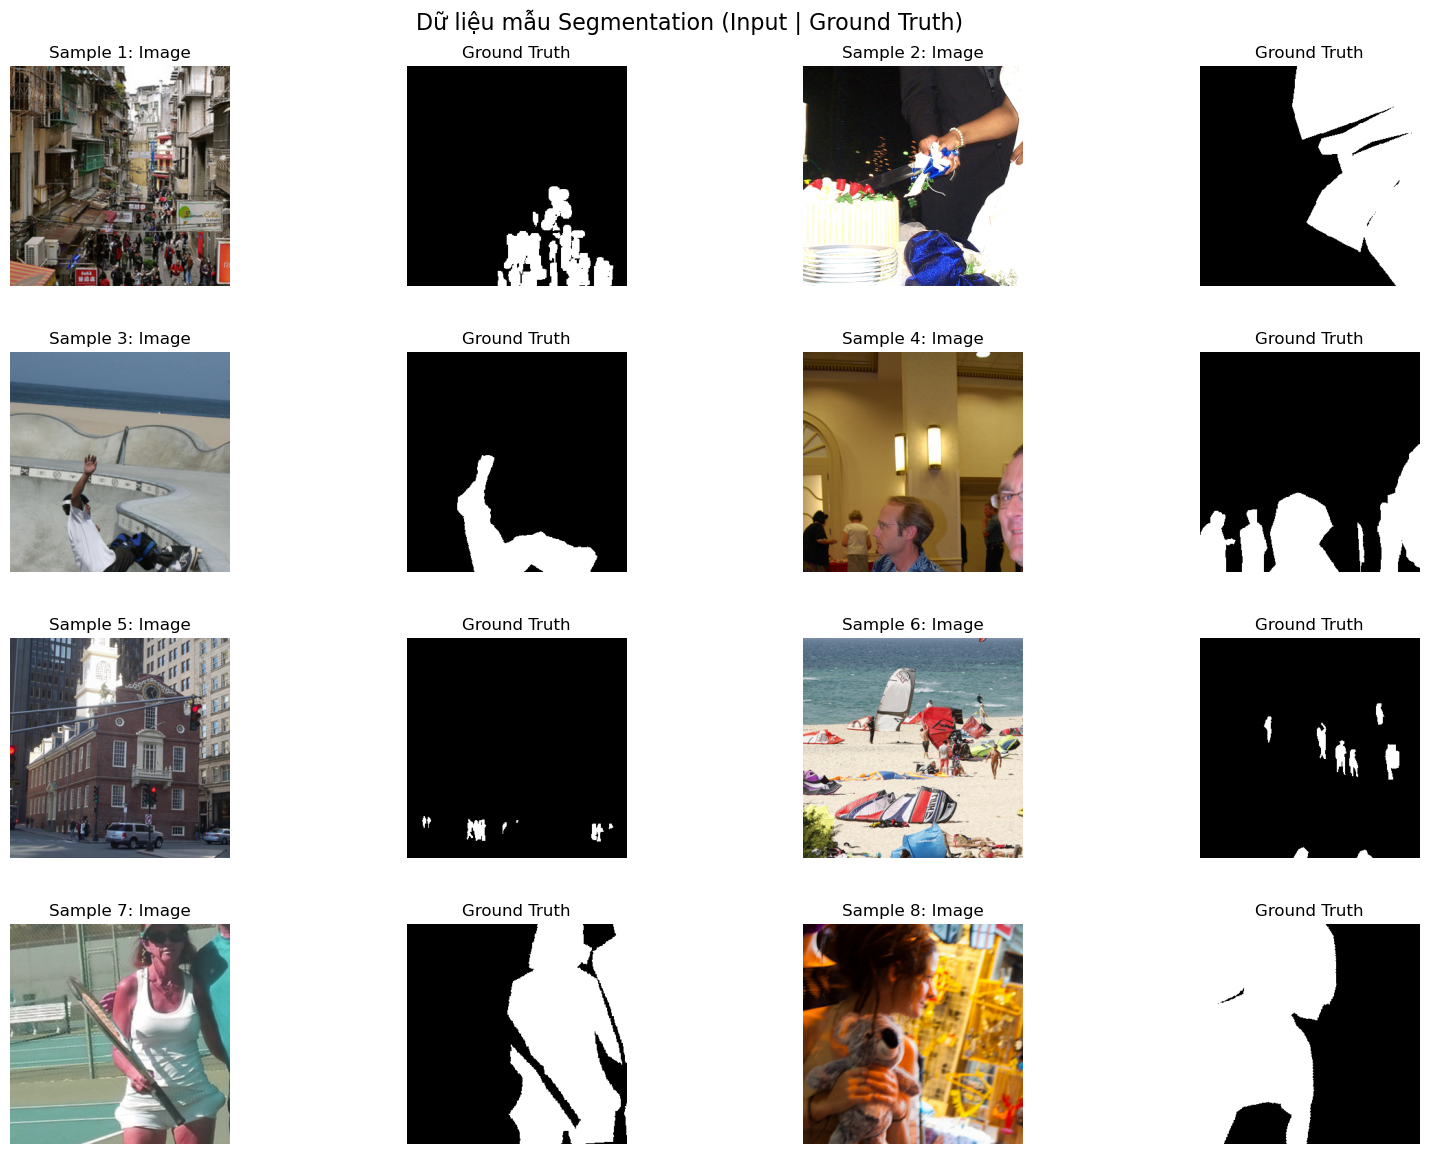

In [9]:
train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=NUM_WORKERS,  
    pin_memory=True 
)

visualize_datasets(train_loader)

In [10]:
print("Đang tải COCO Val Annotations...")
val_dataset = COCOPersonDataset(VAL_IMG_DIR, VAL_ANN_FILE, image_size=(320, 320), is_train = False)

Đang tải COCO Val Annotations...
loading annotations into memory...
Done (t=1.40s)
creating index...
index created!


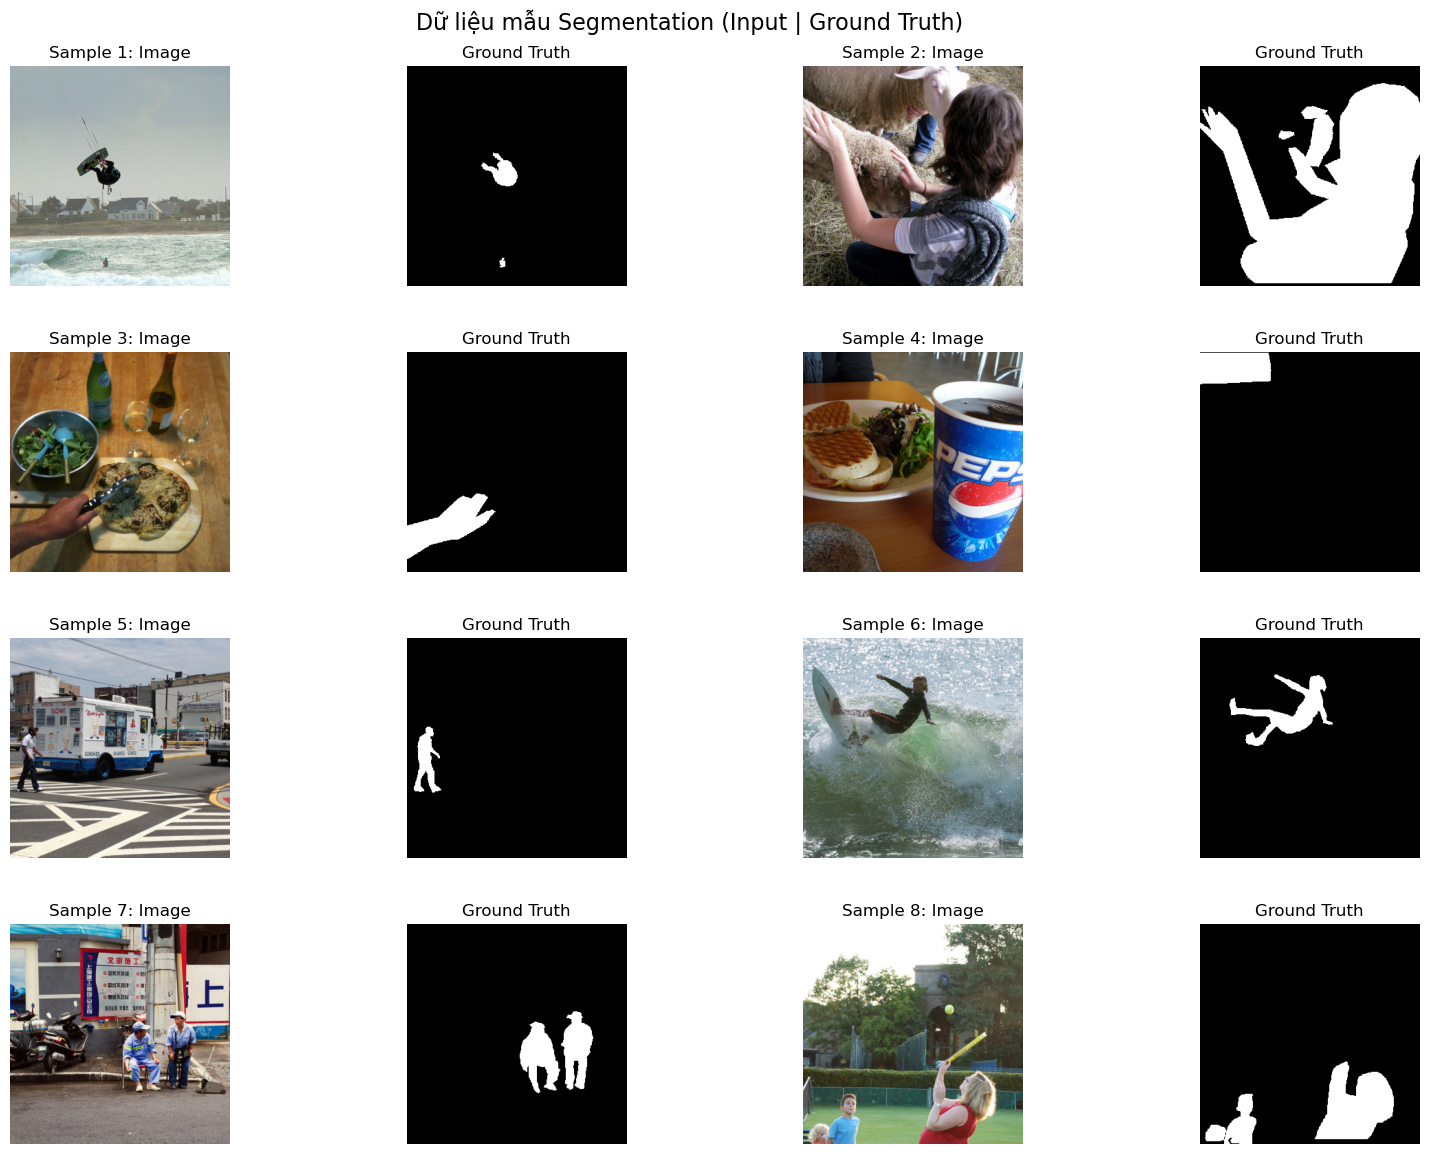

In [11]:
val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False,
    num_workers=NUM_WORKERS,  
    pin_memory=True 
)
visualize_datasets(val_loader)

In [12]:
print(f"Tìm thấy {len(train_dataset)} ảnh Train và {len(val_dataset)} ảnh Val chứa người.")

Tìm thấy 64115 ảnh Train và 2693 ảnh Val chứa người.


In [13]:

model = model.to(device)

scaler = torch.cuda.amp.GradScaler(enabled=device.type == 'cuda')
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

best_val_loss = float('inf')

history = {
    'train_loss': [],
    'val_loss': [],
    'val_iou': []
}
early_stop_counter = 0       

/tmp/ipykernel_202341/3226379831.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=device.type == 'cuda')


In [ ]:
for epoch in range(EPOCH):
    model.train()
    train_loss = 0.0
    
    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCH} [Train]", unit="batch")
    for images, masks in train_bar:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=device.type == 'cuda'):
            outputs = model(images)
            loss = criterion(outputs, masks)
            
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()
        train_bar.set_postfix(loss=f"{loss.item():.4f}")

    avg_train_loss = train_loss / len(train_loader)

    model.eval()
    val_loss = 0.0
    val_iou = 0.0
    
    val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCH} [Val]", unit="batch", leave=False)
    with torch.no_grad():
        for images, masks in val_bar:
            images = images.to(device)
            masks = masks.to(device)

            with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=device.type == 'cuda'):
                outputs = model(images)
                loss = criterion(outputs, masks)

            val_loss += loss.item()
            val_iou += calculate_iou(outputs, masks)

    avg_val_loss = val_loss / len(val_loader)
    avg_val_iou = val_iou / len(val_loader)
    
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['val_iou'].append(avg_val_iou)

    print(f"-> Epoch {epoch+1} Kết thúc | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val IoU: {avg_val_iou:.4f}")
    

    checkpoint_state = {
        'epoch': epoch + 1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'val_loss': avg_val_loss,
        'val_iou': avg_val_iou,
        'history': history  
    }
    last_save = os.path.join(SAVE_MODEL_DIR, "last_unet_base.pth")
    
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        early_stop_counter = 0 
        
        best_save = os.path.join(SAVE_MODEL_DIR, "best_unet_base.pth")
        torch.save(checkpoint_state, best_save)
        print(f"Đã cập nhật mô hình tốt nhất tại: {best_save}\n")
    else:
        print("\n")
        if (epoch + 1) > min_epochs_before_stop:
            early_stop_counter += 1
            print(f"[Cảnh báo] Validation Loss không giảm. Lần {early_stop_counter}/{patience} (Early Stopping)")
            if early_stop_counter >= patience:
                print(f"==== EARLY STOPPING KÍCH HOẠT: Dừng huấn luyện sớm tại Epoch {epoch+1} ====")
                torch.save(checkpoint_state, last_save)
                break
                
    torch.save(checkpoint_state, last_save)

Epoch 1/100 [Train]:  69%|██████▉   | 2768/4008 [05:43<02:38,  7.85batch/s, loss=0.3696]

In [ ]:
train_his_file = os.path.join(SAVE_MODEL_DIR, "training_history.json")
with open(train_his_file, "w") as f:
    json.dump(history, f, indent=4)
print(f"\nQuá trình huấn luyện hoàn tất! Đã xuất {train_his_file}.")

In [ ]:
def plot_training_history(history_source):
    """
    Hàm vẽ biểu đồ Loss và IoU từ quá trình huấn luyện.
    
    Tham số:
    history_source: Có thể là dictionary `history` hoặc đường dẫn string tới file JSON.
    """
    if isinstance(history_source, str) and os.path.exists(history_source):
        print(f"Đang đọc dữ liệu từ file: {history_source}")
        with open(history_source, "r") as f:
            history = json.load(f)
    elif isinstance(history_source, dict):
        history = history_source
    else:
        raise ValueError("Đầu vào phải là dictionary 'history' hoặc đường dẫn tới file JSON.")

    train_loss = history.get('train_loss', [])
    val_loss = history.get('val_loss', [])
    val_iou = history.get('val_iou', [])
    
    epochs = range(1, len(train_loss) + 1)
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_loss, 'b-', label='Train Loss', linewidth=2)
    plt.plot(epochs, val_loss, 'r-', label='Validation Loss', linewidth=2)
    plt.title('Training and Validation Loss', fontsize=14)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, val_iou, 'g-', label='Validation IoU', linewidth=2)
    plt.title('Validation IoU', fontsize=14)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('IoU Score', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

In [ ]:
plot_training_history(history)

In [ ]:
def visualize_predictions(model, dataloader, device, num_samples=8):
    """
    Trực quan hóa kết quả dự đoán của mô hình Segmentation.
    Mỗi sample hiển thị: Ảnh gốc | Ground Truth | Prediction.
    """
    model.eval()
    samples_shown = 0
    
    fig, axes = plt.subplots(nrows=4, ncols=6, figsize=(20, 14))
    plt.subplots_adjust(wspace=0.1, hspace=0.3)
    inv_normalize = transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )

    with torch.no_grad():
        for images, masks in dataloader:
            images = images.to(device)
            masks = masks.to(device)
            with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=device.type == 'cuda'):
                outputs = model(images)
            preds = torch.sigmoid(outputs) > 0.5
            images = images.cpu()
            masks = masks.cpu()
            preds = preds.cpu()

            for i in range(images.size(0)):
                if samples_shown >= num_samples:
                    break
                row = samples_shown // 2
                col_offset = (samples_shown % 2) * 3
                img = inv_normalize(images[i]).permute(1, 2, 0).numpy()
                gt_mask = masks[i].squeeze().numpy()
                pred_mask = preds[i].squeeze().numpy()

                ax_img = axes[row, col_offset]
                ax_img.imshow(img)
                ax_img.set_title(f"Sample {samples_shown+1}: Image")
                ax_img.axis('off')

                ax_gt = axes[row, col_offset + 1]
                ax_gt.imshow(gt_mask, cmap='gray')
                ax_gt.set_title("Ground Truth")
                ax_gt.axis('off')

                ax_pred = axes[row, col_offset + 2]
                ax_pred.imshow(pred_mask, cmap='gray')
                ax_pred.set_title("Prediction")
                ax_pred.axis('off')

                samples_shown += 1

            if samples_shown >= num_samples:
                break

    plt.suptitle("Đánh giá mô hình Segmentation (Input | Ground Truth | Prediction)", fontsize=16, y=0.92)
    plt.show()

In [ ]:
best_model_path = os.path.join(SAVE_MODEL_DIR, "best_unet_base.pth")
best_checkpoint = torch.load(best_model_path) 
model.load_state_dict(best_checkpoint['model_state_dict'])

print("\nĐang trực quan hóa kết quả...")
visualize_predictions(model, val_loader, device, num_samples=8)

In [ ]:
def apply_color_mask(image, mask, color=(0.0, 1.0, 0.0), alpha=0.5):
    """
    Phủ một lớp màu bán trong suốt lên vùng có mask.
    - image: mảng numpy ảnh gốc (H, W, 3), giá trị [0, 1]
    - mask: mảng numpy nhị phân (H, W), giá trị 0 hoặc 1
    - color: tuple màu RGB (mặc định Xanh lá)
    - alpha: độ trong suốt (0.0 -> 1.0)
    """
    colored_image = image.copy()
    for c in range(3):
        colored_image[:, :, c] = np.where(
            mask > 0,
            image[:, :, c] * (1 - alpha) + alpha * color[c],
            image[:, :, c]
        )
    return np.clip(colored_image, 0, 1)

def visualize_predictions_colored(model, dataloader, device, num_samples=8):
    model.eval()
    samples_shown = 0
    
    fig, axes = plt.subplots(nrows=4, ncols=6, figsize=(20, 14))
    plt.subplots_adjust(wspace=0.1, hspace=0.3)
    
    inv_normalize = transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )

    with torch.no_grad():
        for images, masks in dataloader:
            images = images.to(device)
            masks = masks.to(device)

            with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=device.type == 'cuda'):
                outputs = model(images)
            
            preds = torch.sigmoid(outputs) > 0.5

            images = images.cpu()
            masks = masks.cpu()
            preds = preds.cpu()

            for i in range(images.size(0)):
                if samples_shown >= num_samples:
                    break
                
                row = samples_shown // 2
                col_offset = (samples_shown % 2) * 3

                img = inv_normalize(images[i]).permute(1, 2, 0).numpy()
                img = np.clip(img, 0, 1)

                gt_mask = masks[i].squeeze().numpy()
                pred_mask = preds[i].squeeze().numpy()

                gt_overlay = apply_color_mask(img, gt_mask, color=(0.0, 1.0, 0.0), alpha=0.5)
                pred_overlay = apply_color_mask(img, pred_mask, color=(1.0, 0.0, 0.0), alpha=0.5)

                ax_img = axes[row, col_offset]
                ax_img.imshow(img)
                ax_img.set_title(f"Sample {samples_shown+1}")
                ax_img.axis('off')

                ax_gt = axes[row, col_offset + 1]
                ax_gt.imshow(gt_overlay)
                ax_gt.set_title("Truth (Green)")
                ax_gt.axis('off')

                ax_pred = axes[row, col_offset + 2]
                ax_pred.imshow(pred_overlay)
                ax_pred.set_title("Pred (Red)")
                ax_pred.axis('off')

                samples_shown += 1

            if samples_shown >= num_samples:
                break

    plt.suptitle("Đánh giá mô hình Segmentation (Overlay Màu)", fontsize=18, y=0.92, fontweight='bold')
    plt.show()

In [ ]:
print("\nĐang trực quan hóa kết quả...")
visualize_predictions_colored(model, val_loader, device, num_samples=8)

In [ ]:
print("\nĐang trực quan hóa kết quả...")
visualize_predictions_colored(model, train_loader, device, num_samples=8)